# 1.2 Bird's eye view of Quantum Metal

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials/1%20Overview/1.2%20Bird%27s%20eye%20view%20of%20Quantum%20Metal.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2F1%20Overview%2F1.2%20Bird%27s%20eye%20view%20of%20Quantum%20Metal.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API (`gui.rebuild()`, `gui.screenshot()`, `gui.edit_component(...)`) as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

In [2]:
# Three lines to your first superconducting qubit
import qiskit_metal as qm
from qiskit_metal import designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design = designs.DesignPlanar()
q1 = TransmonPocket(
    design,
    "Q1",
    options=dict(
        pos_x="0.5mm",
        pos_y="0.25mm",
        connection_pads=dict(a=dict(loc_W=+1, loc_H=+1)),
    ),
)
fig = qm.view(design)
fig

<Figure size 800x800 with 1 Axes>

> **What just happened?**
>
> In a few lines you:
> 1. Created a **quantum chip design canvas** (`DesignPlanar`)
> 2. Placed a **superconducting transmon qubit** on it (`TransmonPocket`)
> 3. Rendered it to a **matplotlib figure** — no Qt, no GUI, no extra setup
>
> The rest of this tutorial unpacks what each step means and how to control every detail.
> Skip ahead to [1.2 Your First Chip](./1.1-Quick-start.ipynb) if you want to keep building immediately.

## The Quantum Metal design flow

Designing a superconducting chip in Quantum Metal is a four-step loop:

1. **Pick a design canvas** (``DesignPlanar``, ``DesignFlipChip``, ...).
2. **Place QComponents** — transmons, couplers, routes, terminations.
3. **Render** to your backend of choice: GDS for fabrication, HFSS/Q3D or open FEM (gmsh + Elmer / AWS Palace) for simulation.
4. **Analyse** — Hamiltonian, capacitance, eigenmodes, EPR.

This tutorial focuses on the first two steps and shows both the inline matplotlib view (``qm.view``) and the desktop GUI (``MetalGUI``) — ``qm.gui(design)`` picks the right one automatically.

### Step 1 → 4: from design to fab

```mermaid
flowchart LR
    A[<b>1. Design</b><br/><code>DesignPlanar()</code><br/>Pick a chip canvas]
    B[<b>2. Place QComponents</b><br/>Transmons, couplers,<br/>routes, terminations]
    C[<b>3. Render</b><br/>GDS, HFSS / Q3D,<br/>gmsh + Elmer / Palace]
    D[<b>4. Analyse</b><br/>Hamiltonian, capacitance,<br/>eigenmodes, EPR]
    A --> B --> C --> D
    D -. iterate .-> B
    classDef pri fill:#6929C4,stroke:#3D1773,color:#fff
    classDef sec fill:#e8defc,stroke:#6929C4,color:#1a1a1a
    class A,C pri
    class B,D sec
```

This tutorial focuses on **steps 1 and 2** — creating a design and adding components. Tutorial 1.3 covers step 3 (export to GDS); the 4-Analysis tutorials cover step 4.


### How to follow along

You can run Quantum Metal in three ways:

- **Jupyter / Colab / Binder** — interactive, fastest for exploration. The Colab badge at the top of this notebook installs the lite (no-Qt) wheel in seconds.
- **Plain Python scripts** — for reproducible CI / batch runs.
- **Desktop ``MetalGUI``** — the Qt-based interactive editor (``pip install 'quantum-metal[gui]'``).

The same Python API drives all three. ``qm.gui(design)`` returns the desktop GUI when Qt is available, an inline viewer otherwise — your tutorial code is identical in both paths.

### What lives inside a `QDesign`

```mermaid
flowchart TB
    subgraph design[QDesign — the chip canvas]
        components[design.components<br/><i>Dict of QComponent instances</i>]
        variables[design.variables<br/><i>shared option values</i>]
        chips[design.chips<br/><i>chip stack + materials</i>]
        qg[design.qgeometry<br/><i>per-component shapely tables</i>]
    end

    qc[QComponent subclasses<br/>TransmonPocket, RouteMeander, ...] --> components
    components -. options -.-> qg
    components -. pins -.-> components

    qg --> rend[QRenderer]
    rend --> gds[GDS file]
    rend --> hfss[HFSS / Q3D project]
    rend --> fem[gmsh + Elmer / Palace]

    classDef inner fill:#f4f1fb,stroke:#6929C4,color:#1a1a1a
    classDef outer fill:#6929C4,stroke:#3D1773,color:#fff
    class components,variables,chips,qg inner
    class qc,rend outer
```

Every `QComponent` you instantiate registers itself on `design.components`. Calling `gui.rebuild()` (or `design.rebuild()`) re-runs each component's `make()` against current option values and refreshes `design.qgeometry`. Renderers consume that geometry to produce GDS files, HFSS/Q3D projects, or open-FEM meshes.


### Building blocks

Quantum Metal organises a chip around a few abstractions:

- **``QComponent``** — a physical piece (transmon, CPW, launchpad). You instantiate subclasses, not ``QComponent`` itself.
- **``QDesign``** — the chip canvas; holds components, variables, and chip geometry.
- **``QRenderer``** — converts the design to a target format (GDS, HFSS, Q3D, gmsh, Elmer, ...).
- **``QGeometry``** — the per-component shapely shapes (polygons, paths, junctions).

### Import Quantum Metal

In [3]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import open_docs

%metal_heading Welcome to Qiskit Metal!

If you see the welcome banner, the install is healthy. Onward.

### Create a design

Every chip starts from a ``QDesign``. ``DesignPlanar`` is the simplest — a single planar chip.

In [4]:
design = designs.DesignPlanar()

### Re-running cells safely

While iterating you'll re-instantiate components a lot. Tell the design to overwrite previous versions silently:

In [5]:
design.overwrite_enabled = True

In [6]:
%metal_heading Hello Quantum World!

### Chip dimensions

Each design has a default chip called ``main``. Inspect or resize it via ``design.chips.main.size``.

In [7]:
# We can also check all of the chip properties to see if we want to change the size or any other parameter.
# By default the name of chip is "main".
design.chips.main

{'material': 'silicon',
 'layer_start': '0',
 'layer_end': '2048',
 'size': {'center_x': '0.0mm',
  'center_y': '0.0mm',
  'center_z': '0.0mm',
  'size_x': '9mm',
  'size_y': '6mm',
  'size_z': '-750um',
  'sample_holder_top': '890um',
  'sample_holder_bottom': '1650um'}}

Update any dimension by assigning to the dict; ``gui.rebuild()`` propagates the change.

In [8]:
design.chips.main.size.size_x = "11mm"
design.chips.main.size.size_y = "9mm"

### Launching the viewer

``qm.gui(design)`` returns either the desktop ``MetalGUI`` (Qt) or ``MetalGUIHeadless`` (inline matplotlib). The tutorial-facing API — ``gui.rebuild()``, ``gui.autoscale()``, ``gui.screenshot()``, ``gui.edit_component(...)`` — is the same in both.

In [9]:
gui = qm.gui(design)

# Dark theme for the desktop GUI screenshots below. Guarded because the
# inline headless viewer used on Colab/Binder has no stylesheet concept.
if hasattr(gui, "load_stylesheet"):
    gui.load_stylesheet("metal_dark")

10:42PM 09s WARNING [_qt_message_handler]: WARNING: Populating font family aliases took 152 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost.  (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes
    if await self.run_code(code, result, async_=asy):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/pyt

10:42PM 09s WARNING [_qt_message_handler]: WARNING: This plugin does not support propagateSizeHints() (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3178, in _run_cell
    result = runner(coro)
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes
    if await self.run_code(code,

10:42PM 09s WARNING [_qt_message_handler]: WARNING: This plugin does not support propagateSizeHints() (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3123, in run_cell
    result = self._run_cell(
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3178, in _run_cell
    result = runner(coro)
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "

Either a Qt window opens or an inline figure renders below. Either way you're ready to place components.

### Place your first qubit

Time to add a ``TransmonPocket`` — a ready-made transmon from ``qiskit_metal.qlibrary.qubits``.

In [10]:
# Select a QComponent to create (The QComponent is a python class named `TransmonPocket`)
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket


q1 = TransmonPocket(
    design, "Q1", options=dict(connection_pads=dict(a=dict()))
)  # Create a new Transmon Pocket object with name 'Q1'
gui.rebuild()  # rebuild the design and plot

gui.edit_component("Q1")  # set Q1 as the editable component
gui.autoscale()  # resize GUI to see QComponent

10:42PM 09s WARNING [_qt_message_handler]: WARNING: This plugin does not support propagateSizeHints() (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes
    if await self.run_code(code, result, async_=asy):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/ll/v2l8gv4n6v59qrqlsc0jf3dc0000gn/T/ipykernel_31589/3284350283.py", line 11, in <module>
    gui.autoscale()  # resize GUI

10:42PM 09s WARNING [_qt_message_handler]: WARNING: This plugin does not support raise() (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes
    if await self.run_code(code, result, async_=asy):
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/ll/v2l8gv4n6v59qrqlsc0jf3dc0000gn/T/ipykernel_31589/3284350283.py", line 11, in <module>
    gui.autoscale()  # resize GUI to see QComponent
  File "/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/src/qiskit_metal/_gui/main_window.py", line 1422, in autoscale
    self.plot_win.auto_scale(include_chip=include_chip)
  File "/Users/zlatkominev/CODE_REPOS/quan

Print the component object to inspect its name, type, and resolved options:

In [11]:
q1  # print Q1 information

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
       'a'                 : {
            'pad_gap'           : '15um',                       
            'pad_width'         : '125um',                      
            'pad_height'        : '30um',                       
            'pad_cpw_shift'     : '5um',                        
            'pad_cpw_extent'    : '25um',                       
            'cpw_width'         : 'cpw_width',                  
            'cpw_gap'           : 'cpw_gap',                    
            'cpw_extend'        : '100um',                      
            'pocket_extent'     : '5um',                        
            'pocket_rise'    

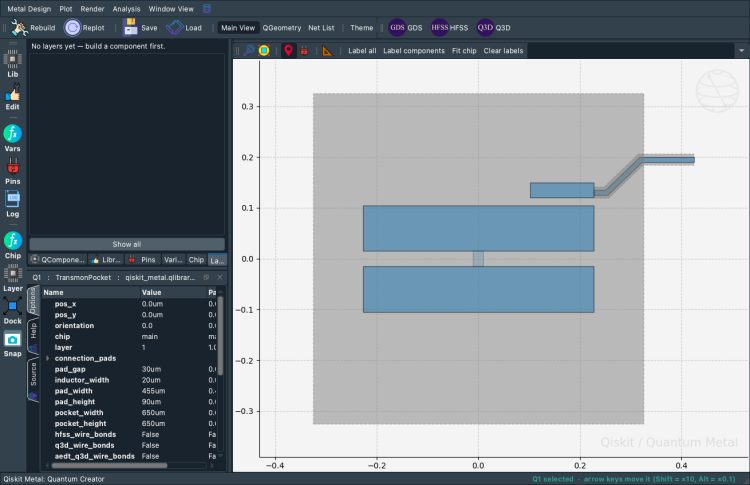

In [12]:
gui.screenshot()  # screenshot of the design in GUI

#### Default options

Each ``QComponent`` ships with a ``default_options`` dict (pad sizes, position, layer, etc.). Quantum Metal parses the strings into numbers during ``make()``. You can change options through the GUI or the Python API — they call the same setters.

In [13]:
%metal_print How do I edit options?  API or GUI

### Updating components

Mutate ``q1.options.<field>`` and call ``gui.rebuild()``. The GUI re-renders the geometry from the new options.

In [14]:
# Change options
q1.options.pos_x = "0.5 mm"
q1.options.pos_y = "0.25 mm"
q1.options.pad_height = "225 um"
q1.options.pad_width = "250 um"
q1.options.pad_gap = "50 um"

### Rebuilding

``gui.rebuild()`` re-runs every component's ``make()`` against current option values and updates the displayed geometry. Call it after any option change.

In [15]:
gui.rebuild()  # Update the component geometry, since we changed the options

# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

# An alternate way to view within GUI. If want to try it, remove the "#" from the beginning of line.
# gui.autoscale() #resize GUI

AttributeError: 'PySide6.QtWidgets.QTreeView' object has no attribute 'autoresize_columns'

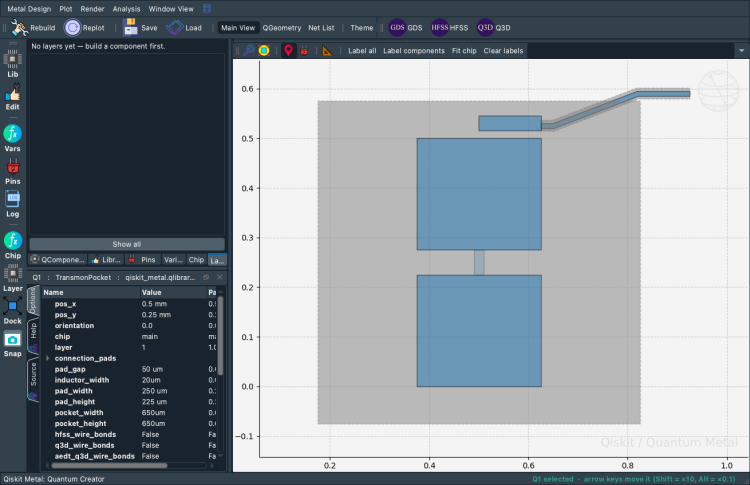

In [16]:
gui.screenshot()  # screenshot of the design in GUI

### Closing the viewer

In [17]:
# gui.main_window.close()

### Next steps

Tutorial [1.1 Quick start](./1.1-Quick-start.ipynb) walks through the same flow in more depth, including variables, pin-to-pin connections with ``RouteMeander``, and a full 4-qubit chip. For an entirely Qt-free walk, see [1.1 Quick start](./1.1-Quick-start.ipynb).

In [18]:
%matplotlib inline

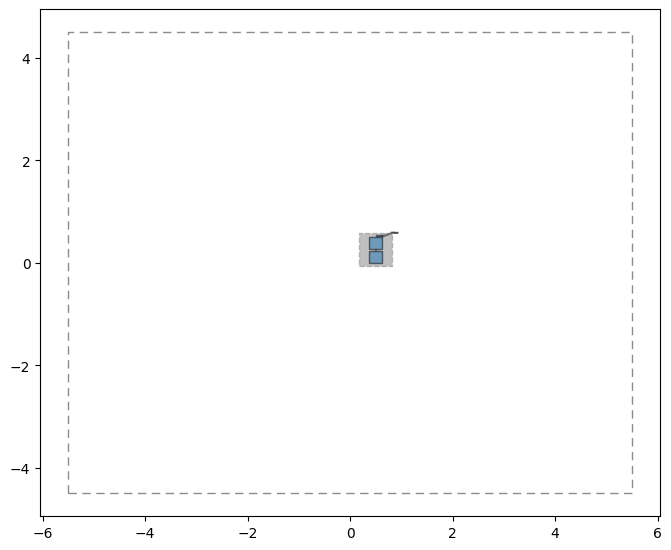

In [19]:
fig = qm.view(design)
fig  # inline-display in Jupyter; fig.savefig("...") to write to file